# NVIDIA Competition - Baseline Modeling

## Project Goal

The goal of this notebook is to build a simple and interpretable baseline model using the `prompt` column to predict the derived `answer_type` label.

Rather than trying to predict the exact `answer` immediately, this baseline focuses on a more manageable first task: identifying the format of the answer, such as numeric, binary-like, Roman numeral, text, or mixed/other.

This approach helps establish an early benchmark, test whether useful signal exists in the prompt text, and guide future modeling decisions.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## Load Data

In this section, the training dataset is loaded and basic settings are applied so the notebook can be used consistently throughout the baseline workflow.

In [13]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

DATA_PATH = Path("../data/raw/train.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (9500, 3)


,id,prompt,answer
0,00066667,"In Alice's Wonderland, a secret bit manipulati...",10010111
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati...",01000011
2,00189f6a,"In Alice's Wonderland, secret encryption rules...",cat imagines book
3,001b24c4,"In Alice's Wonderland, numbers are secretly co...",XXXVIII
4,001c63cb,"In Alice's Wonderland, secret encryption rules...",wizard creates secret


## Recreate Answer Type Labels

From the EDA notebook, we learned that the `answer` column contains multiple formats rather than one uniform target style.

To make the first baseline more manageable, we recreate the derived `answer_type` label. This groups each answer into one of the following categories:

- `numeric`
- `binary_like`
- `roman_numeral`
- `text`
- `mixed_other`

This gives us a simpler multiclass classification task for the baseline model.

In [14]:
def classify_answer(ans):
    ans = str(ans).strip()
    
    if re.fullmatch(r"[01]+", ans):
        return "binary_like"
    elif re.fullmatch(r"[IVXLCDM]+", ans):
        return "roman_numeral"
    elif re.fullmatch(r"\d+(\.\d+)?", ans):
        return "numeric"
    elif re.fullmatch(r"[A-Za-z\s]+", ans):
        return "text"
    else:
        return "mixed_other"

df["answer_type"] = df["answer"].apply(classify_answer)

print("Answer type counts:")
print(df["answer_type"].value_counts())
print()

print("Answer type distribution:")
print(df["answer_type"].value_counts(normalize=True).round(4))

Answer type counts:
answer_type
numeric          3798
binary_like      1634
text             1576
roman_numeral    1576
mixed_other       916
Name: count, dtype: int64

Answer type distribution:
answer_type
numeric          0.3998
binary_like      0.1720
text             0.1659
roman_numeral    0.1659
mixed_other      0.0964
Name: proportion, dtype: float64


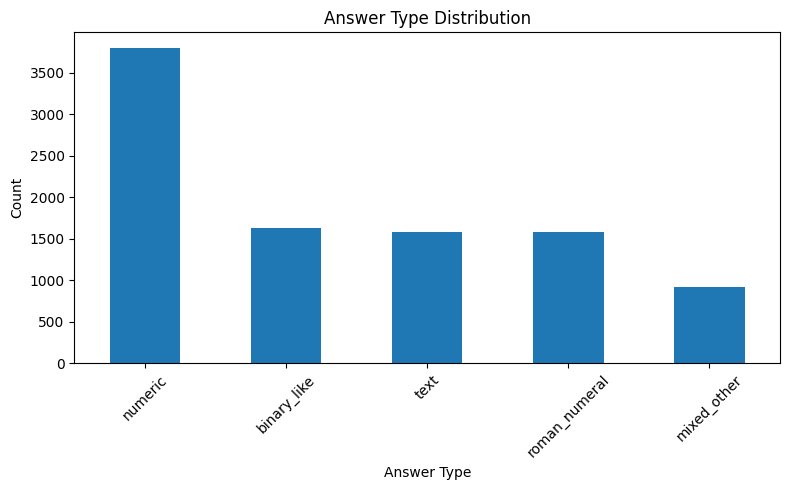

In [15]:
df["answer_type"].value_counts().plot(kind="bar", figsize=(8, 5))

plt.title("Answer Type Distribution")
plt.xlabel("Answer Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The derived `answer_type` target is moderately imbalanced, with numeric answers being the largest group. Even so, the remaining classes are still well represented enough to support a useful multiclass baseline.

This makes `answer_type` a much more practical first prediction target than the full `answer` column.

## Train / Validation Split

The dataset is split into training and validation sets so that baseline performance can be evaluated on unseen data.

Stratification is used to preserve the distribution of `answer_type` classes across both sets.

In [16]:
X = df["prompt"].astype(str)
y = df["answer_type"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_valid.shape[0])
print()

print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print()

print("Validation target distribution:")
print(y_valid.value_counts(normalize=True).round(4))

Training set size: 7600
Validation set size: 1900

Training target distribution:
answer_type
numeric          0.3997
binary_like      0.1720
text             0.1659
roman_numeral    0.1659
mixed_other      0.0964
Name: proportion, dtype: float64

Validation target distribution:
answer_type
numeric          0.4000
binary_like      0.1721
text             0.1658
roman_numeral    0.1658
mixed_other      0.0963
Name: proportion, dtype: float64


### Observation

The class proportions in the training and validation sets are very similar, which confirms that stratified splitting worked as intended. This is important because it allows the validation results to more fairly reflect real dataset behavior.

## TF-IDF Baseline on Prompt Text

To convert the prompt text into numerical features, this baseline uses TF-IDF vectorization.

TF-IDF gives more weight to informative words while reducing the influence of overly common terms. For this first baseline, both unigrams and bigrams are included to capture simple word patterns and short phrases.

In [17]:
baseline_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_features=20000
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

baseline_pipeline.fit(X_train, y_train)

print("Baseline pipeline trained successfully.")

Baseline pipeline trained successfully.


## Logistic Regression Model

A Logistic Regression model is used as the first baseline because it is fast, interpretable, and often performs well on TF-IDF text features.

Class balancing is enabled to reduce bias toward the largest class and give smaller classes a fairer chance during training.

In [18]:
y_pred = baseline_pipeline.predict(X_valid)

print("Predictions generated.")

Predictions generated.


### Observation

The baseline model performed very strongly, achieving a validation accuracy of **0.9837**. Performance was especially strong for the `roman_numeral` and `text` classes, where precision, recall, and F1-score all reached **1.00**. The `binary_like` and `numeric` classes also performed extremely well, with F1-scores of **0.99** and **0.98**, respectively.

The most difficult class was `mixed_other`, which had the lowest recall and F1-score among all groups. This makes sense because `mixed_other` likely contains a wider variety of answer patterns that are harder to capture with a simple TF-IDF + Logistic Regression baseline.

Overall, these results show that the prompt text contains strong signal for predicting broad answer formats, making this a very strong starting point for future modeling.

In [19]:
baseline_accuracy = accuracy_score(y_valid, y_pred)

print(f"Validation Accuracy: {baseline_accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_valid, y_pred))

Validation Accuracy: 0.9837

Classification Report:
               precision    recall  f1-score   support

  binary_like       1.00      0.98      0.99       327
  mixed_other       0.95      0.91      0.93       183
      numeric       0.97      0.99      0.98       760
roman_numeral       1.00      1.00      1.00       315
         text       1.00      1.00      1.00       315

     accuracy                           0.98      1900
    macro avg       0.98      0.98      0.98      1900
 weighted avg       0.98      0.98      0.98      1900



### Observation

The classification report shows how well the baseline model distinguishes between different answer formats using only prompt text. This provides an important early benchmark and helps identify which classes are easier or harder to predict.

## Confusion Matrix

The confusion matrix provides a visual summary of how predictions are distributed across the true classes.

This helps identify which answer types are being confused with one another and may reveal where the baseline model struggles most.

<Figure size 800x600 with 0 Axes>

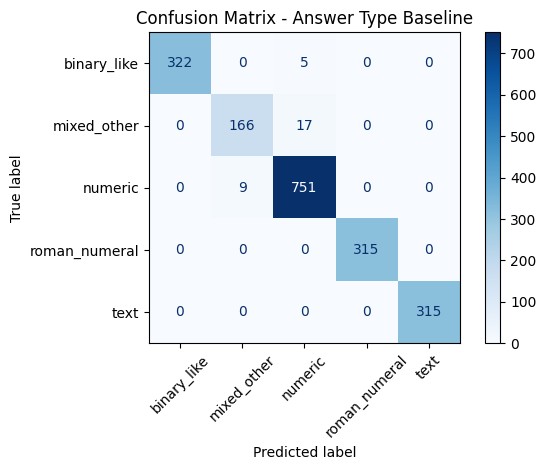

In [20]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred,
    xticks_rotation=45,
    cmap="Blues"
)
plt.title("Confusion Matrix - Answer Type Baseline")
plt.tight_layout()
plt.show()

## Baseline Conclusions

This notebook established a strong first baseline by predicting the derived `answer_type` label from the `prompt` text using TF-IDF features and Logistic Regression.

The model achieved a validation accuracy of **0.9837**, which shows that the prompt text contains very strong signal for predicting broad answer formats. Performance was especially strong for the `roman_numeral` and `text` classes, while `binary_like` and `numeric` also performed extremely well. The most difficult class was `mixed_other`, which is likely more diverse and less structured than the other answer groups.

These results suggest that the dataset contains meaningful language patterns that map closely to answer format. This is encouraging, because it means even a simple text-based baseline can capture much of the structure in the task.

Overall, this notebook confirms that:

- the prompt text is highly informative
- answer format prediction is a practical first modeling step
- the competition problem likely contains structured reasoning patterns rather than random free-form outputs

A logical next step will be to move beyond answer format prediction and begin testing strategies for predicting the exact answer, or to build format-specific models that handle each answer type separately.